In [ ]:
# =======================================
# STEP 1: Mount Drive & Setup Paths
# =======================================
from google.colab import drive
import os, shutil
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

original_dataset = "/content/drive/MyDrive/Dataset"  # ✅ Must contain only 2 folders: Organic, Recyclable
base_dir = "/content/drive/MyDrive/waste_dataset_mobilenet"

classes = ["Organic", "Recyclable"]


Mounted at /content/drive


In [ ]:
# =======================================
# STEP 2: Prepare Train/Val Split
# =======================================
for split in ["train", "val"]:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

print("📊 Splitting dataset...")
for cls in classes:
    cls_dir = os.path.join(original_dataset, cls)
    images = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        shutil.copy2(os.path.join(cls_dir, img), os.path.join(base_dir, "train", cls, img))
    for img in val_imgs:
        shutil.copy2(os.path.join(cls_dir, img), os.path.join(base_dir, "val", cls, img))

    print(f"{cls}: Train={len(train_imgs)}, Val={len(val_imgs)}")

print("✅ Dataset split complete.")

📊 Splitting dataset...
Organic: Train=236, Val=59
Recyclable: Train=424, Val=106
✅ Dataset split complete.


In [ ]:
# =======================================
# STEP 3: Data Generators
# =======================================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_dir = os.path.join(base_dir,"train")
val_dir = os.path.join(base_dir,"val")

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=42
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False, seed=42
)

print(f"🏷 Class indices: {train_generator.class_indices}")

Found 660 images belonging to 2 classes.
Found 165 images belonging to 2 classes.
🏷 Class indices: {'Organic': 0, 'Recyclable': 1}


In [ ]:
# =======================================
# STEP 4: Build MobileNetV2 Model
# =======================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation="softmax")(x)  # ✅ 2 classes

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,434 (9.87 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# =======================================
# STEP 5: Callbacks
# =======================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("/content/drive/MyDrive/best_mobilenet_waste.h5", monitor="val_accuracy", save_best_only=True, verbose=1)
]

In [ ]:
# =======================================
# STEP 6: Stage 1 Training (Frozen Base)
# =======================================
print("🚀 Stage 1: Training with frozen base...")
history_stage1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)


🚀 Stage 1: Training with frozen base...
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9841 - loss: 0.0409
Epoch 1: val_accuracy did not improve from 0.99394
21/21 ━━━━━━━━━━━━━━━━━━━━ 155s 7s/step - accuracy: 0.9841 - loss: 0.0408 - val_accuracy: 0.9879 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9842 - loss: 0.0427
Epoch 2: val_accuracy did not improve from 0.99394
21/21 ━━━━━━━━━━━━━━━━━━━━ 150s 7s/step - accuracy: 0.9843 - loss: 0.0424 - val_accuracy: 0.9939 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9912 - loss: 0.0341
Epoch 3: val_accuracy did not improve from 0.99394
21/21 ━━━━━━━━━━━━━━━━━━━━ 156s 8s/step - accuracy: 0.9912 - loss: 0.0339 - val_accuracy: 0.9939 - val_loss: 0.0277 - learning_rate: 0.0010
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9942 - loss: 0.0242
Epoch 4: val_accuracy did not improve from 0.99394
21/2

In [ ]:
# =======================================
# STEP 7: Stage 2 Fine-tuning
# =======================================
print("🔧 Stage 2: Fine-tuning last layers...")
base_model.trainable = True
for layer in base_model.layers[:-20]:  # unfreeze last 20 layers
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history_stage2 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)


🔧 Stage 2: Fine-tuning last layers...
Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8743 - loss: 0.3311
Epoch 1: val_accuracy did not improve from 0.99394
21/21 ━━━━━━━━━━━━━━━━━━━━ 163s 7s/step - accuracy: 0.8756 - loss: 0.3281 - val_accuracy: 0.9939 - val_loss: 0.0217 - learning_rate: 1.0000e-05
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9294 - loss: 0.1771
Epoch 2: val_accuracy did not improve from 0.99394
21/21 ━━━━━━━━━━━━━━━━━━━━ 144s 7s/step - accuracy: 0.9294 - loss: 0.1769 - val_accuracy: 0.9939 - val_loss: 0.0201 - learning_rate: 1.0000e-05
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9644 - loss: 0.1170
Epoch 3: val_accuracy did not improve from 0.99394
21/21 ━━━━━━━━━━━━━━━━━━━━ 169s 8s/step - accuracy: 0.9644 - loss: 0.1164 - val_accuracy: 0.9939 - val_loss: 0.0197 - learning_rate: 1.0000e-05
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9716 - loss: 0.0690
Epoch 4: val_accuracy did not improve from 0.

In [ ]:
# =======================================
# STEP 8: Final Evaluation
# =======================================
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"✅ Final Validation Accuracy: {val_acc:.4f}, Loss: {val_loss:.4f}")

✅ Final Validation Accuracy: 0.9939, Loss: 0.0217


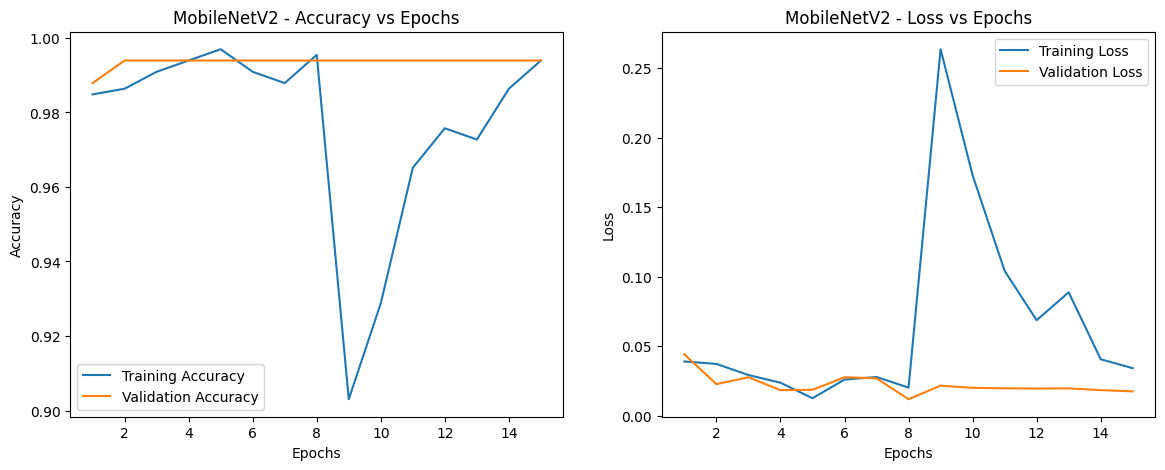

In [ ]:
# =======================================
# STEP 9: Training Curves (Accuracy & Loss)
# =======================================
import matplotlib.pyplot as plt

# Combine Stage 1 & 2 histories
history = {}
for k in history_stage1.history.keys():
    history[k] = history_stage1.history[k] + history_stage2.history[k]

epochs = range(1, len(history["accuracy"]) + 1)

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Accuracy vs Epochs")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, history["loss"], label="Training Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Loss vs Epochs")
plt.legend()

plt.show()


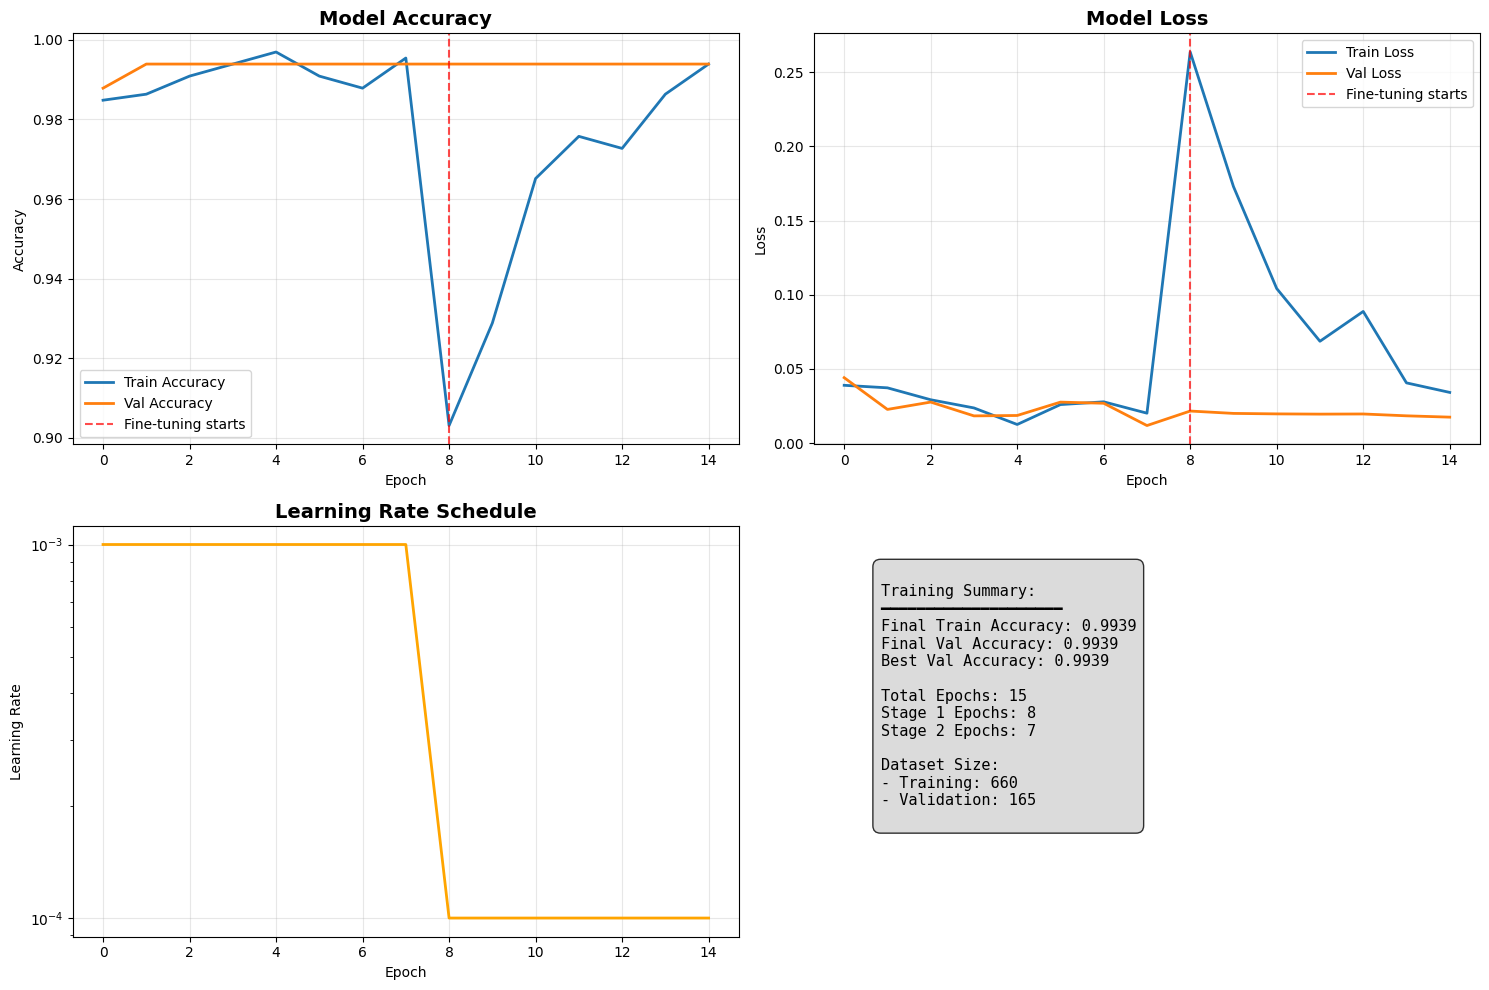

In [ ]:
# =======================================
# STEP 8: Combine Training History
# =======================================
# Combine histories from both stages
history_combined = {}
for key in history_stage1.history.keys():
    history_combined[key] = history_stage1.history[key] + history_stage2.history[key]

# Define the number of epochs in stage 1
EPOCHS_STAGE1 = len(history_stage1.history['loss'])

# =======================================
# STEP 9: Enhanced Visualization
# =======================================
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Accuracy plot
plt.subplot(2, 2, 1)
plt.plot(history_combined['accuracy'], label="Train Accuracy", linewidth=2)
plt.plot(history_combined['val_accuracy'], label="Val Accuracy", linewidth=2)
plt.axvline(x=EPOCHS_STAGE1, color='red', linestyle='--', alpha=0.7, label='Fine-tuning starts')
plt.title("Model Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(2, 2, 2)
plt.plot(history_combined['loss'], label="Train Loss", linewidth=2)
plt.plot(history_combined['val_loss'], label="Val Loss", linewidth=2)
plt.axvline(x=EPOCHS_STAGE1, color='red', linestyle='--', alpha=0.7, label='Fine-tuning starts')
plt.title("Model Loss", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Learning rate plot (if available)
plt.subplot(2, 2, 3)
total_epochs = len(history_combined['loss'])
lr_values = [0.001] * EPOCHS_STAGE1 + [0.0001] * (total_epochs - EPOCHS_STAGE1)
plt.plot(lr_values, linewidth=2, color='orange')
plt.title("Learning Rate Schedule", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Training summary
plt.subplot(2, 2, 4)
plt.axis('off')
final_train_acc = history_combined['accuracy'][-1]
final_val_acc = history_combined['val_accuracy'][-1]
best_val_acc = max(history_combined['val_accuracy'])

summary_text = f"""
Training Summary:
━━━━━━━━━━━━━━━━━━━━
Final Train Accuracy: {final_train_acc:.4f}
Final Val Accuracy: {final_val_acc:.4f}
Best Val Accuracy: {best_val_acc:.4f}

Total Epochs: {total_epochs}
Stage 1 Epochs: {EPOCHS_STAGE1}
Stage 2 Epochs: {total_epochs - EPOCHS_STAGE1}

Dataset Size:
- Training: {train_generator.samples}
- Validation: {val_generator.samples}
"""

plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_results.png', dpi=300, bbox_inches='tight')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step

📊 Classification Report:
              precision    recall  f1-score   support

     Organic       0.98      1.00      0.99        59
  Recyclable       1.00      0.99      1.00       106

    accuracy                           0.99       165
   macro avg       0.99      1.00      0.99       165
weighted avg       0.99      0.99      0.99       165



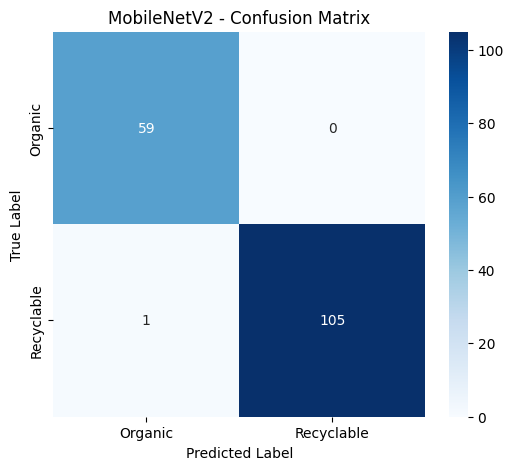

In [ ]:

# =======================================
# STEP 10: Classification Report & Confusion Matrix
# =======================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_proba = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

class_labels = list(val_generator.class_indices.keys())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 - Confusion Matrix")
plt.show()

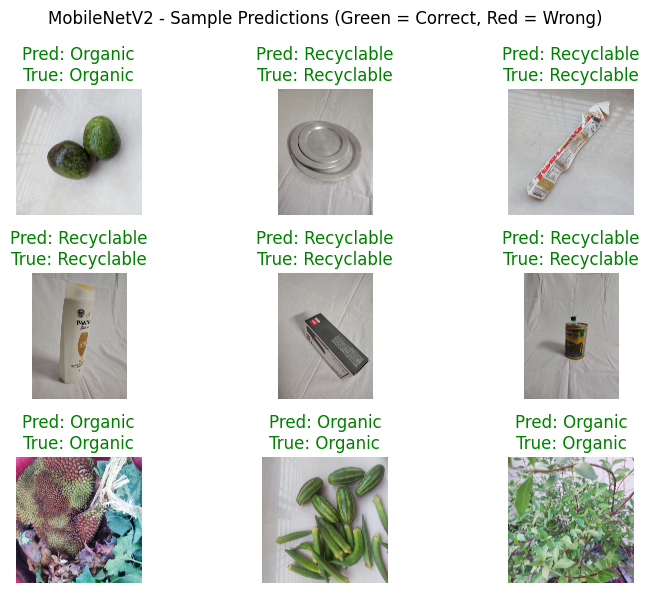

In [ ]:
# =======================================
# STEP 11: Visualize Predictions
# =======================================
import random
from tensorflow.keras.preprocessing import image

plt.figure(figsize=(8,6))
for i in range(9):
    idx = random.randint(0, len(y_true)-1)
    img_path = val_generator.filepaths[idx]

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_label = class_labels[np.argmax(pred)]
    true_label = class_labels[y_true[idx]]

    plt.subplot(3,3,i+1)
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    color = "green" if pred_label==true_label else "red"
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)

plt.suptitle("MobileNetV2 - Sample Predictions (Green = Correct, Red = Wrong)", fontsize=12)
plt.tight_layout()
plt.show()